# 07 -- Feature Engineering

Feature engineering for day-ahead electricity price forecasting must respect one hard
constraint: **gate closure**. The Nordic day-ahead auction closes at 12:00 CET on D-1.
Any feature used for delivery day D must be available before that deadline.

This means:
- Lag features must use `shift(24)` at minimum, not `shift(1)`. Using `shift(1)` leaks
  future information -- the price at hour H-1 is not known when bidding for hour H.
- Wind/solar forecasts from TSO are available D-1 morning. Actuals are not.
- Calendar features (hour, weekday, holidays) are deterministic and always available.

| Feature family | Available | Source |
|----------------|-----------|--------|
| Price lags (1d, 2d, 7d) | D-1 13:00 CET | Market results |
| Rolling price stats | D-1 13:00 CET | Derived from lags |
| Load forecast | D-1 10:00 CET | TSO (Energinet/ENTSO-E) |
| Wind/solar forecast | D-1 10:00 CET | TSO |
| Residual load | D-1 10:00 CET | Computed: load - wind - solar |
| Calendar (hour, weekday, holiday) | Always | Deterministic |
| Cross-border flows | D-1 14:00 CET | ENTSO-E TP |

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from da_forecast.data import load_prices, load_wind_solar, load_load, load_all
from da_forecast.features import (
    compute_lag_features,
    compute_calendar_features,
    compute_fundamental_features,
    build_feature_matrix,
)
from da_forecast.config import FEATURE_AVAILABILITY

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

## 1. Load Data

In [2]:
prices = load_prices("DK_1")
wind_solar = load_wind_solar("DK_1")
load_forecast = load_load("DK_1")

# Align all to the price index
common_idx = prices.index.intersection(wind_solar.index).intersection(load_forecast.index)
prices = prices.loc[common_idx]
wind_solar = wind_solar.loc[common_idx]
load_forecast = load_forecast.loc[common_idx]

print(f"Aligned data: {len(common_idx)} hours")
print(f"Date range: {common_idx.min()} -> {common_idx.max()}")

Loaded DK_1 prices from 'energinet': 8758 hours (2024-10-01 -> 2025-09-30)
Loaded DK_1 wind/solar from 'energinet': 8738 hours
Loaded DK_1 load from 'energinet': 8746 hours
Aligned data: 8728 hours
Date range: 2024-10-01 00:00:00+00:00 -> 2025-09-30 21:00:00+00:00


## 2. Lag Features

All lag features use `shift(24)` or more to ensure they are available before gate
closure. Rolling statistics are also shifted by 24h before the window is applied.

In [3]:
lag_df = compute_lag_features(prices)

print("Lag feature columns:")
for col in lag_df.columns:
    na_pct = lag_df[col].isna().mean() * 100
    print(f"  {col:30s}  NaN: {na_pct:.1f}%")

# Correlation of each lag feature with the target price
print("\nCorrelation with price_eur_mwh:")
lag_cols = [c for c in lag_df.columns if c != "price_eur_mwh"]
for col in lag_cols:
    r = lag_df["price_eur_mwh"].corr(lag_df[col])
    print(f"  {col:30s}  r = {r:.4f}")

Lag feature columns:
  price_eur_mwh                   NaN: 0.0%
  price_lag_1d                    NaN: 0.3%
  price_lag_2d                    NaN: 0.5%
  price_lag_7d                    NaN: 1.9%
  price_rolling_7d_mean           NaN: 0.5%
  price_rolling_7d_std            NaN: 0.5%
  price_rolling_24h_min           NaN: 0.5%
  price_rolling_24h_max           NaN: 0.5%

Correlation with price_eur_mwh:
  price_lag_1d                    r = 0.6059
  price_lag_2d                    r = 0.3867
  price_lag_7d                    r = 0.3063
  price_rolling_7d_mean           r = 0.1435
  price_rolling_7d_std            r = -0.0254
  price_rolling_24h_min           r = 0.3092
  price_rolling_24h_max           r = 0.1932


## 3. Lag Feature Scatter Plots

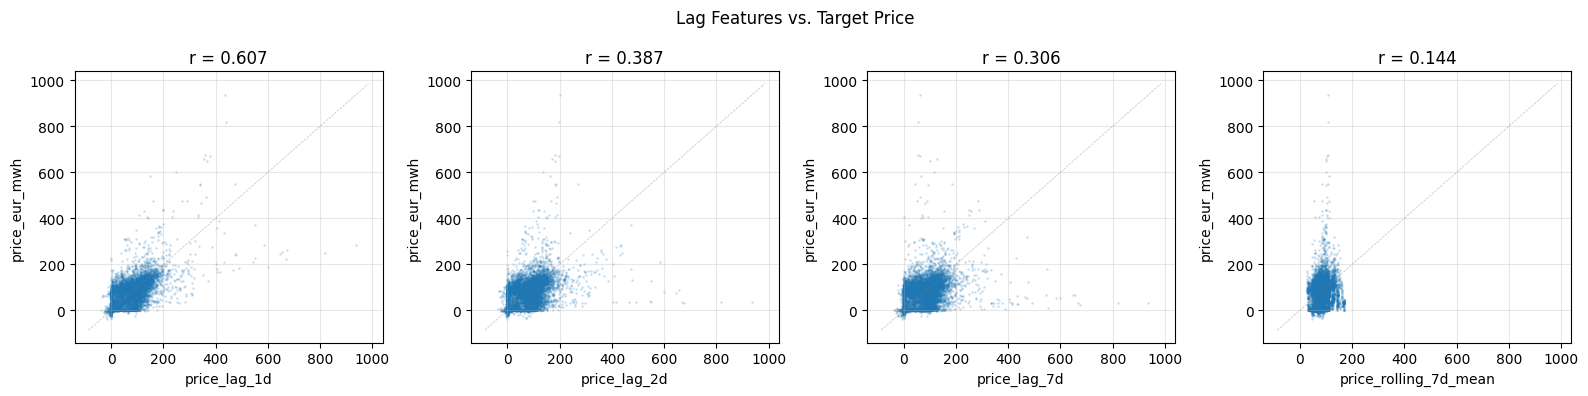

In [4]:
scatter_cols = ["price_lag_1d", "price_lag_2d", "price_lag_7d", "price_rolling_7d_mean"]
scatter_cols = [c for c in scatter_cols if c in lag_df.columns]

fig, axes = plt.subplots(1, len(scatter_cols), figsize=(4 * len(scatter_cols), 4))
if len(scatter_cols) == 1:
    axes = [axes]

clean = lag_df.dropna()
for ax, col in zip(axes, scatter_cols):
    ax.scatter(clean[col], clean["price_eur_mwh"], s=1, alpha=0.15)
    r = clean[col].corr(clean["price_eur_mwh"])
    ax.set_xlabel(col)
    ax.set_ylabel("price_eur_mwh")
    ax.set_title(f"r = {r:.3f}")
    # 45-degree reference line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, "--", color="grey", linewidth=0.5, alpha=0.5)
    ax.grid(True, alpha=0.3)

plt.suptitle("Lag Features vs. Target Price", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Calendar Features

Cyclical features use sin/cos encoding so that adjacent values remain close in
feature space. Without this encoding, hour 23 and hour 0 appear maximally distant
to tree-based models.

Danish public holidays are included -- load profiles on holidays resemble Sundays.

In [5]:
cal_df = compute_calendar_features(prices)

cal_cols = ["hour_sin", "hour_cos", "weekday_sin", "weekday_cos", "is_weekend", "is_holiday"]
print("Calendar feature columns:")
for col in cal_cols:
    if col in cal_df.columns:
        print(f"  {col:20s}  min={cal_df[col].min():.3f}  max={cal_df[col].max():.3f}")

# Show holidays found
n_holiday_hours = cal_df["is_holiday"].sum()
n_holiday_days = n_holiday_hours // 24 if n_holiday_hours > 0 else 0
print(f"\nHoliday hours: {n_holiday_hours} (~{n_holiday_days} days)")
print(f"Weekend hours: {cal_df['is_weekend'].sum()}")

Calendar feature columns:
  hour_sin              min=-1.000  max=1.000
  hour_cos              min=-1.000  max=1.000
  weekday_sin           min=-0.975  max=0.975
  weekday_cos           min=-0.901  max=1.000
  is_weekend            min=0.000  max=1.000
  is_holiday            min=0.000  max=1.000

Holiday hours: 240 (~10 days)
Weekend hours: 2496


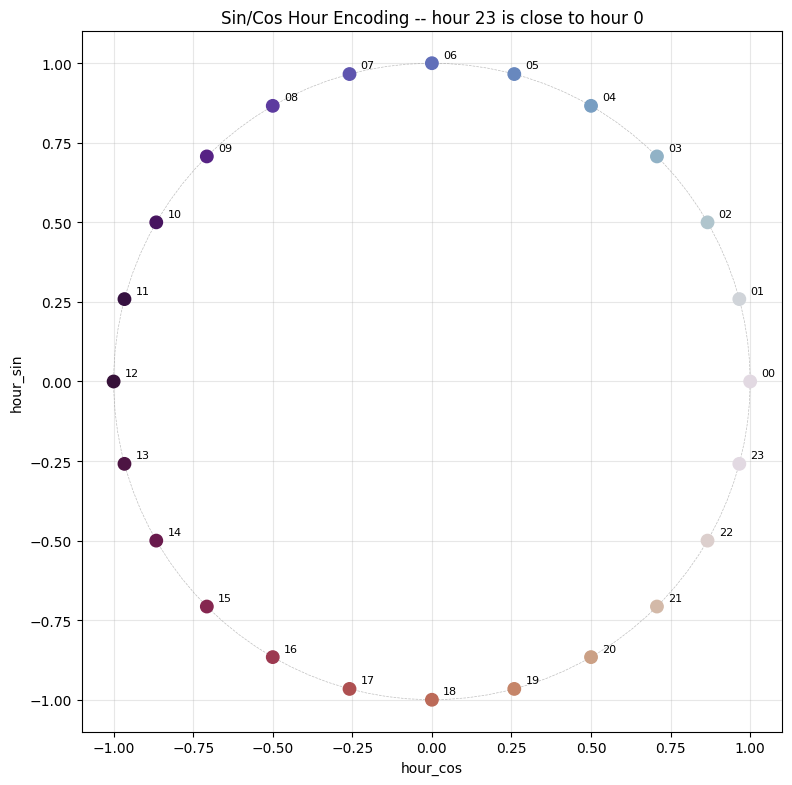

In [6]:
# Visualize sin/cos hour encoding
fig, ax = plt.subplots(figsize=(8, 8))

sample = cal_df.head(24)  # one day
hours = sample.index.tz_convert("Europe/Copenhagen").hour
ax.scatter(sample["hour_cos"], sample["hour_sin"], c=hours, cmap="twilight", s=80, zorder=5)
for h, cos_v, sin_v in zip(hours, sample["hour_cos"], sample["hour_sin"]):
    ax.annotate(f"{h:02d}", (cos_v, sin_v), textcoords="offset points",
                xytext=(8, 4), fontsize=8)

# Draw unit circle
theta = np.linspace(0, 2 * np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), "--", color="grey", linewidth=0.5, alpha=0.5)
ax.set_xlabel("hour_cos")
ax.set_ylabel("hour_sin")
ax.set_title("Sin/Cos Hour Encoding -- hour 23 is close to hour 0")
ax.set_aspect("equal")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Fundamental Features

**Residual load** = total load - wind generation - solar generation.

This is the main price driver through the merit order: when residual load is high,
expensive gas/coal plants must run, pushing prices up. When residual load is low
(high wind), only cheap renewables are needed and prices drop -- sometimes below zero.

In [7]:
# Prepare wind and solar DataFrames for compute_fundamental_features
wind_cols = [c for c in wind_solar.columns if "wind" in c.lower()]
solar_cols = [c for c in wind_solar.columns if "solar" in c.lower()]

wind_df = pd.DataFrame({"wind_mw": wind_solar[wind_cols].sum(axis=1)}, index=wind_solar.index)
solar_df = pd.DataFrame({"solar_mw": wind_solar[solar_cols[0]] if solar_cols else 0}, index=wind_solar.index)

fund_df = compute_fundamental_features(load_forecast, wind_df, solar_df)

print("Fundamental feature columns:")
for col in fund_df.columns:
    print(f"  {col:25s}  mean={fund_df[col].mean():.0f}  std={fund_df[col].std():.0f}")

# Residual load vs price correlation
merged = fund_df.join(prices, how="inner")
r = merged["residual_load_mw"].corr(merged["price_eur_mwh"])
print(f"\nCorrelation(residual_load, price): {r:.4f}")

Fundamental feature columns:
  load_mw                    mean=2658  std=437
  wind_mw                    mean=1633  std=1235
  solar_mw                   mean=359  std=566
  residual_load_mw           mean=665  std=1166

Correlation(residual_load, price): 0.5857


## 6. Full Feature Matrix

`build_feature_matrix()` assembles all feature families into a single DataFrame
aligned to the price index.

In [8]:
feature_matrix = build_feature_matrix(
    prices=prices,
    load_forecast=load_forecast,
    wind_solar_forecast=wind_solar,
)

print(f"Feature matrix shape: {feature_matrix.shape}")
print(f"\nColumns:")
for col in feature_matrix.columns:
    na_pct = feature_matrix[col].isna().mean() * 100
    print(f"  {col:30s}  NaN: {na_pct:.1f}%")

# Drop rows with NaN (mostly from lag warm-up period)
clean_matrix = feature_matrix.dropna()
print(f"\nClean rows (after dropping NaN): {len(clean_matrix)} / {len(feature_matrix)}")

Feature matrix shape: (8728, 19)

Columns:
  price_eur_mwh                   NaN: 0.0%
  price_lag_1d                    NaN: 0.3%
  price_lag_2d                    NaN: 0.5%
  price_lag_7d                    NaN: 1.9%
  price_rolling_7d_mean           NaN: 0.5%
  price_rolling_7d_std            NaN: 0.5%
  price_rolling_24h_min           NaN: 0.5%
  price_rolling_24h_max           NaN: 0.5%
  hour_sin                        NaN: 0.0%
  hour_cos                        NaN: 0.0%
  weekday_sin                     NaN: 0.0%
  weekday_cos                     NaN: 0.0%
  is_weekend                      NaN: 0.0%
  is_holiday                      NaN: 0.0%
  residual_load_mw                NaN: 0.0%
  load_mw                         NaN: 0.0%
  wind_total_mw                   NaN: 0.0%
  wind_capacity_factor            NaN: 0.0%
  solar_mw                        NaN: 0.0%

Clean rows (after dropping NaN): 8560 / 8728


## 7. Feature Correlation Heatmap

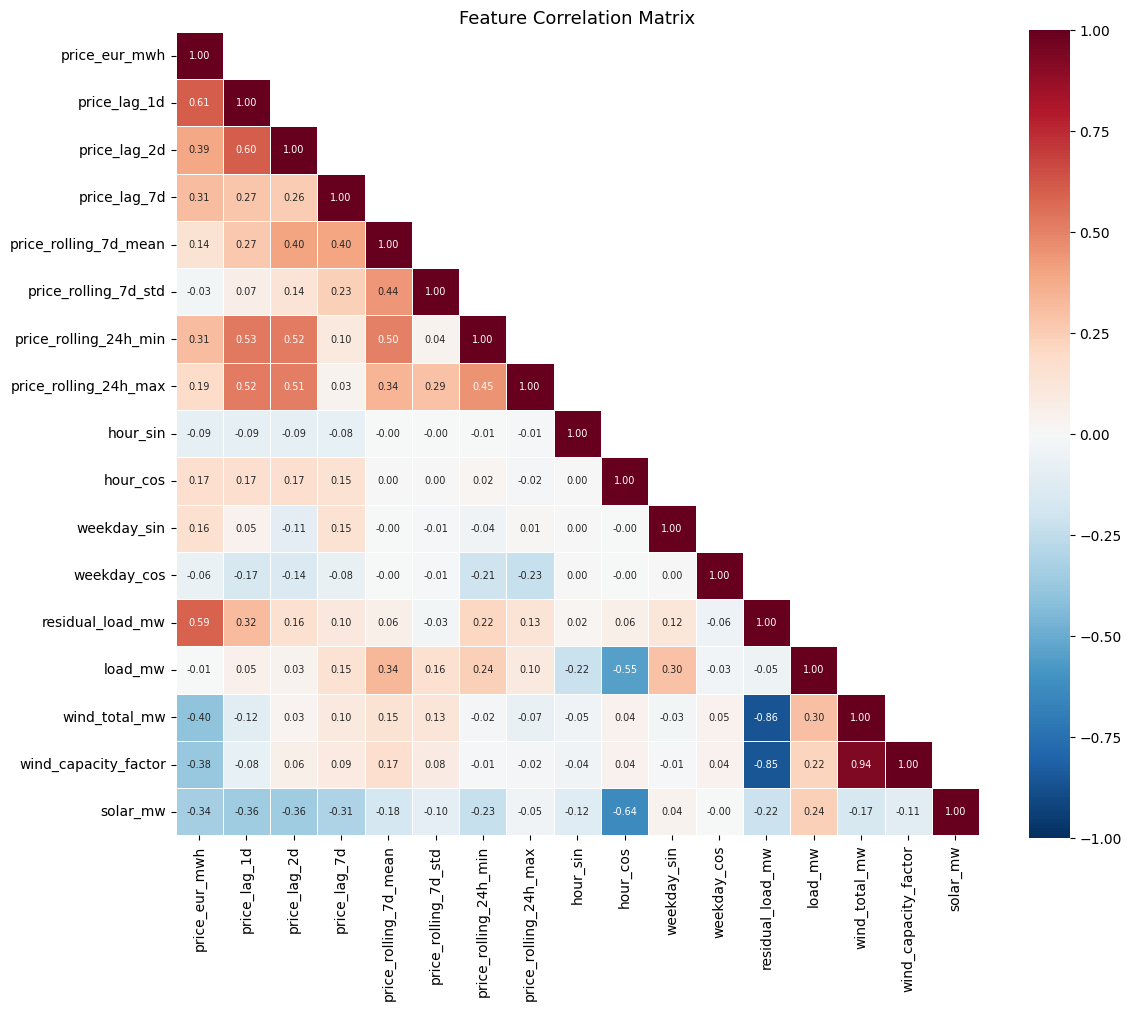

Feature correlations with price_eur_mwh:
  price_lag_1d                    +0.6066
  residual_load_mw                +0.5864
  price_lag_2d                    +0.3865
  price_rolling_24h_min           +0.3116
  price_lag_7d                    +0.3063
  price_rolling_24h_max           +0.1936
  hour_cos                        +0.1716
  weekday_sin                     +0.1611
  price_rolling_7d_mean           +0.1437
  load_mw                         -0.0071
  price_rolling_7d_std            -0.0275
  weekday_cos                     -0.0641
  hour_sin                        -0.0897
  solar_mw                        -0.3426
  wind_capacity_factor            -0.3795
  wind_total_mw                   -0.3994


In [9]:
# Select numeric columns and compute correlations with price
numeric_cols = clean_matrix.select_dtypes(include=[np.number]).columns.tolist()
corr = clean_matrix[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    ax=ax, annot_kws={"size": 7},
)
ax.set_title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# Sorted correlations with target
if "price_eur_mwh" in corr.columns:
    price_corr = corr["price_eur_mwh"].drop("price_eur_mwh").sort_values(ascending=False)
    print("Feature correlations with price_eur_mwh:")
    for feat, r in price_corr.items():
        print(f"  {feat:30s}  {r:+.4f}")

## 8. Look-Ahead Bias Demo

This is the most common pitfall in energy price forecasting. Using `shift(1)` for
the price lag means the model sees the price from the previous hour -- but that
price is not available at gate closure.

Gate closure is at 12:00 CET on D-1, so all 24 delivery hours of day D are bid at
once. The most recent usable price is from D-1, requiring `shift(24)` at minimum.

`shift(1)` will show artificially high correlation and inflated backtest performance
that cannot be replicated in live trading.

In [10]:
price_series = prices["price_eur_mwh"]

# Compare shift(1) vs shift(24)
lag_1h = price_series.shift(1)
lag_24h = price_series.shift(24)

r_1h = price_series.corr(lag_1h)
r_24h = price_series.corr(lag_24h)

print(f"Correlation with shift(1):   {r_1h:.4f}  <-- LEAKS FUTURE INFORMATION")
print(f"Correlation with shift(24):  {r_24h:.4f}  <-- legitimate (available before gate closure)")
print(f"\nDifference: {r_1h - r_24h:.4f}")
print(f"\nUsing shift(1) inflates apparent predictive power by {(r_1h / r_24h - 1) * 100:.0f}%.")
print("This gap translates directly into overstated backtest accuracy.")

Correlation with shift(1):   0.9232  <-- LEAKS FUTURE INFORMATION
Correlation with shift(24):  0.6059  <-- legitimate (available before gate closure)

Difference: 0.3173

Using shift(1) inflates apparent predictive power by 52%.
This gap translates directly into overstated backtest accuracy.


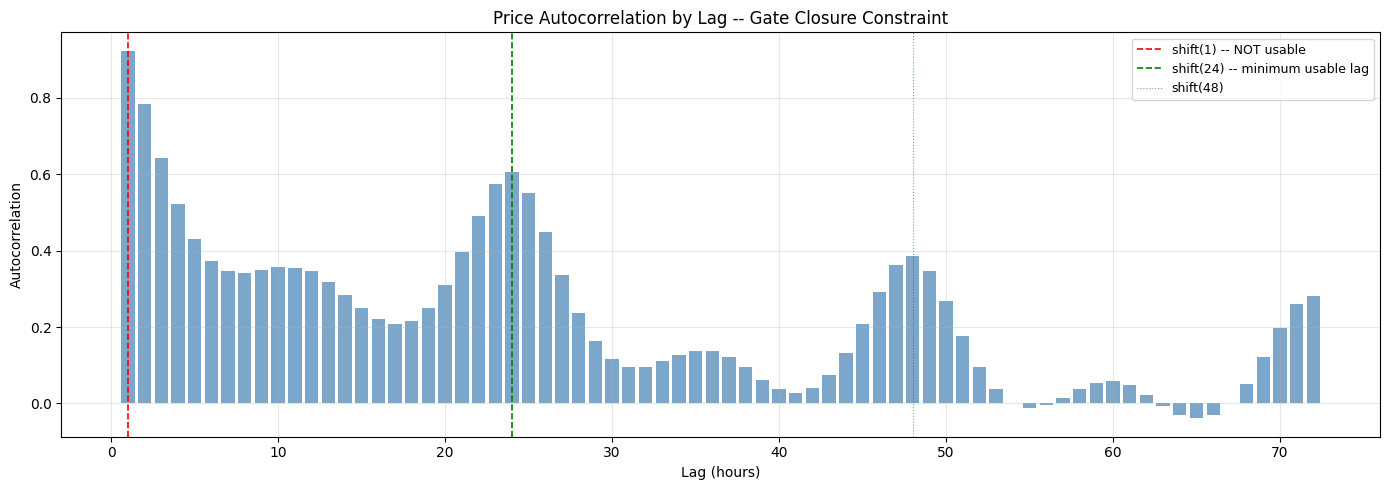

In [11]:
# Visualize the autocorrelation structure
max_lag = 72
autocorr = [price_series.autocorr(lag=h) for h in range(1, max_lag + 1)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(1, max_lag + 1), autocorr, color="steelblue", alpha=0.7)
ax.axvline(x=1, color="red", linestyle="--", linewidth=1.2, label="shift(1) -- NOT usable")
ax.axvline(x=24, color="green", linestyle="--", linewidth=1.2, label="shift(24) -- minimum usable lag")
ax.axvline(x=48, color="green", linestyle=":", linewidth=0.8, alpha=0.6, label="shift(48)")
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")
ax.set_title("Price Autocorrelation by Lag -- Gate Closure Constraint")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Availability Reference

For convenience, the full feature availability table from `da_forecast.config`:

In [12]:
avail_df = pd.DataFrame(
    [(k, v) for k, v in FEATURE_AVAILABILITY.items()],
    columns=["feature", "available_from"],
)
display(avail_df)

,feature,available_from
0,price_lag_1d,D-1 13:00 CET
1,price_lag_2d,D-2 13:00 CET
2,price_lag_7d,D-7 13:00 CET
3,price_rolling_7d_mean,D-1 13:00 CET
4,price_rolling_7d_std,D-1 13:00 CET
5,load_forecast,D-1 10:00 CET
6,wind_forecast,D-1 10:00 CET
7,solar_forecast,D-1 10:00 CET
8,wind_forecast_error_lag1,D-1 end of day
9,residual_load,D-1 10:00 CET


## Summary

- **Gate closure at 12:00 CET** is the binding constraint. All features must use data
  available before that deadline. Lag features require `shift(24)` minimum.
- **Sin/cos encoding** preserves cyclical distance: hour 23 is adjacent to hour 0.
  One-hot encoding of 24 hours would lose this structure and increase dimensionality.
- **Residual load** (load minus wind minus solar) is the primary price driver through
  the merit order. High residual load forces expensive thermal plant online.
- **Look-ahead bias** from `shift(1)` inflates backtest accuracy and cannot be
  replicated in live bidding. Always validate feature availability against the
  gate-closure timeline.